<a href="https://colab.research.google.com/github/ellenyifang2011/presidential_ai_challenge/blob/main/ulam/density_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os, sys
import pandas as pd

def in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

def data_dir() -> str:
    if in_colab():
        # default Colab path after mounting Drive
        return "/content/drive/MyDrive/Data"
    return os.path.abspath("./data")  # local default

def path(*parts) -> str:
    return os.path.join(data_dir(), *parts)

def load_data(filename):
    return pd.read_csv(path(filename))


     x   euler_value   total_primes   density     gauss
0   10           151             10     1.000  0.434294
1  100         10141             86     0.860  0.217147
2  200         40241            156     0.780  0.188739
3  300         90341            210     0.700  0.175322
4  400        160441            270     0.675  0.166904


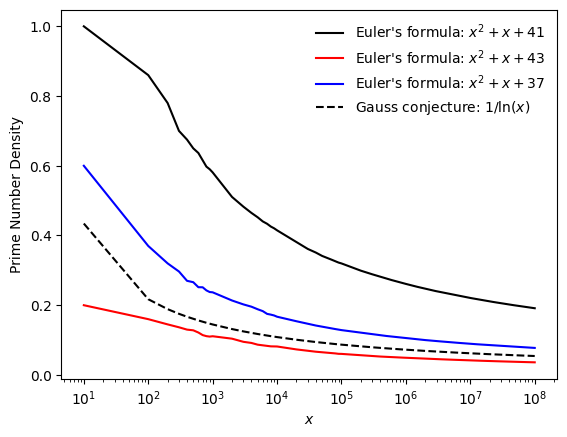

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#df = pd.read_csv("data/output.csv")
#df43 = pd.read_csv("data/output43.csv")
#df37 = pd.read_csv("data/output37.csv")

df = load_data("output41.csv")
df43 = load_data("output43.csv")
df37 = load_data("output37.csv")

df["gauss"] = 1/np.log(df['x'])
print(df.head())
x = df.iloc[:, 0]   # 1st column
y = df.iloc[:, 3]   # 4th column
y1 = df.iloc[:, 4]   # 5th column

x43 = df43.iloc[:, 0]   # 1st column
y43 = df43.iloc[:, 3]   # 4th column

x37 = df37.iloc[:, 0]   # 1st column
y37 = df37.iloc[:, 3]   # 4th column
plt.figure()
#plt.plot(x, y, marker='o')
plt.plot(x, y, linestyle='-', color='black', label=r"Euler's formula: $x^2 + x + 41$")
plt.plot(x43, y43, linestyle='-', color='red', label=r"Euler's formula: $x^2 + x + 43$")
plt.plot(x37, y37, linestyle='-', color='blue', label=r"Euler's formula: $x^2 + x + 37$")
plt.plot(x, y1, linestyle='--', color='black', label=r"Gauss conjecture: $1/\ln(x)$")
plt.xscale("log", base=10)
plt.xlabel(r"$x$")
plt.ylabel("Prime Number Density")
plt.legend(frameon=False)
plt.savefig("polynomial_comparison.png", dpi=300, bbox_inches="tight")
#plt.title("Density of Primes from Euler's Formula")
plt.show()
